<!-- config-banner -->
# DINO 1° — `diffKrT`/`diffKrS` in place of `diffKrFile`: validation (2026-09-09)

**`visc2x`, 1 yr restarted from the spin-up's year-170 pickup** — run 31142
(`baseline/from170yrPk_visc2x`, `nIter0=2986560`, `viscAhD` = `viscAhZ` =
`dino_viscAhD_2p00.bin`) against the 200-yr spin-up 30983's own year 170 → 171.

The 2026-09-09 review of the file-based mixing inputs (setup README, "Lateral
viscosity and vertical diffusivity: file or parameter") replaced
`diffKrFile='dino_diffKr.bin'` — a 51×198×36 field of the single constant
1.2e-5 — with `diffKrT = diffKrS = 1.2E-5` in `PARM01` (DINO's `rn_avt0`), and
found that the lateral viscosity has to stay a `PARM05` file (DINO's law is
A_h = ½·U_v·Δx and MITgcm has no parameter linear in Δx). This notebook is the
evidence, in four parts:

1. **Bitwise checks** — the 1-yr restart against the spin-up (diagnostics,
   pickups, `%MON`), and the three same-executable 30-day pairs made the same
   day: forward 31139 vs 31100, adjoint 31140 vs 31137 (default build), and
   the adjoint-viscosity boost 31141 vs 31138 (which is *expected* to differ,
   part 4).
2. **MOC and AMOC** — the diagnostics of `moc_amoc_animation_200yr_visc2x.ipynb`
   for the restart, overlaid on the spin-up's years 165–171.
3. **Why no `viscAhGrid` reproduces the viscosity file** — run-free, from the
   grid: the file is ∝ cos φ, `viscAhGrid·L²/(4Δt)` is ∝ cos²φ.
4. **The adjoint-viscosity boost's stale `outAd*` values** — what restoring
   the forward's `viscAhGrid=0`, `diffKhT/S=500` after each backward step
   changed relative to the old `1.8E-2` / `0` (31141 vs 31138).

Figures go to the run directory on scratch (`figures/` under 31142), not the repo.
Runs are filed under `runs/{forward,adjoint}/toolchain_validation/`.

In [1]:
import os, glob, filecmp, re, warnings
from fnmatch import fnmatch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xmitgcm.utils as xu
from dinocean.neverworld2.loader import DINOLoader
warnings.filterwarnings("ignore")

RUNS = "/scratch2/tshahriar/DINO_1deg_outputs/runs"
run_dir    = RUNS + "/forward/toolchain_validation/DINO_1deg_frd_1yr_from170yrPk_visc2x_run31142/"
spinup_dir = RUNS + "/forward/spinup_200yr_visc2x/DINO_1deg_frd_200yr_from_rest_visc2x_run30983/"
fwd_new = RUNS + "/forward/toolchain_validation/DINO_1deg_frd_30d_from_rest_visc2x_run31139/"
fwd_ref = RUNS + "/forward/toolchain_validation/DINO_1deg_frd_30d_from_rest_visc2x_run31100/"
adj_new = RUNS + "/adjoint/toolchain_validation/DINO_1deg_tapAdj_nocheckpoint_30d_from180yrPk_visc2x_run31140/"
adj_ref = RUNS + "/adjoint/toolchain_validation/DINO_1deg_tapAdj_nocheckpoint_30d_from180yrPk_visc2x_run31137/"
boost_new = RUNS + "/adjoint/toolchain_validation/DINO_1deg_tapAdj_ckpAll_adjVisc_30d_from_rest_viscRef_run31141/"
boost_ref = RUNS + "/adjoint/toolchain_validation/DINO_1deg_tapAdj_ckpAll_adjVisc_30d_from_rest_viscRef_run31138/"
plain_ref = RUNS + "/adjoint/adjViscBoost/DINO_1deg_tapAdj_ckpAll_30d_from_rest_viscRef_run31026/"   # no boost, same start
mitgrid = "/home/tshahriar/Proj_ImPACTS/impacts-mitgcm/MITgcm_c69m/mysetups/DINO_1deg/input_binaries/tile001.mitgrid"

FIG_DIR = os.path.join(run_dir, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
delta_t = 1800.0
ref = np.datetime64("2000-01-01T00:00:00")
NX, NY, NR = 51, 198, 36
IT0 = 2986560                      # year 170 of the spin-up, 48*366 steps per year
year_iters = [IT0 + 1464 * k for k in range(1, 13)]   # the 12 monthly records of the restart year
for d in (run_dir, spinup_dir, fwd_new, fwd_ref, adj_new, adj_ref, boost_new, boost_ref, plain_ref):
    assert os.path.isdir(d), d

## 1. Bitwise checks

`cmp_dirs` compares every `.data` file of the new run that is not an input
symlink against the same name in the reference; `mon_blocks` splits the
`%MON` stream by `time_tsnumber` so a restart's monitor blocks can be matched
against the corresponding blocks inside the 200-yr spin-up's log. The block
the restart writes at `nIter0` itself is expected to differ in exactly three
lines, the `trAdv_CFL_*_max` maxima, which are still zero before the first
step; every later block must match.

In [2]:
def cmp_dirs(ref_dir, new_dir, names=None, exclude=("dino_", "bathy", "pickup.0002986560", "tile001")):
    files = names if names is not None else sorted(
        f for f in os.listdir(new_dir) if f.endswith(".data") and not f.startswith(exclude))
    same, diff, missing = [], [], []
    for f in files:
        a, b = os.path.join(ref_dir, f), os.path.join(new_dir, f)
        if not (os.path.exists(a) and os.path.exists(b)):
            missing.append(f)
        elif filecmp.cmp(a, b, shallow=False):
            same.append(f)
        else:
            diff.append(f)
    return same, diff, missing

def mon_blocks(stdout):
    blocks, cur, key = {}, [], None
    for line in open(stdout):
        if "%MON" not in line:
            continue
        if "time_tsnumber" in line:
            if key is not None:
                blocks[key] = cur
            key, cur = int(line.split()[-1]), []
        cur.append(line.split("%MON", 1)[1])
    if key is not None:
        blocks[key] = cur
    return blocks

def report(label, same, diff, missing):
    print(f"{label}: {len(same)} identical, {len(diff)} differ, {len(missing)} missing")
    for f in diff[:12]: print("   DIFF   ", f)
    for f in missing[:12]: print("   MISSING", f)

# 1a. the 1-yr restart against the spin-up's own year 170 -> 171
names = [f"{p}.{it:010d}.data" for it in year_iters for p in ("dynDiag", "surfDiag", "atmDiag", "viscDiag", "pickup")]
report("31142 vs spin-up year 171 (4 diagnostics x 12 months + 12 pickups)", *cmp_dirs(spinup_dir, run_dir, names))
mb_new, mb_ref = mon_blocks(run_dir + "STDOUT.0000"), mon_blocks(spinup_dir + "STDOUT.0000")
common = sorted(set(mb_new) & set(mb_ref))
bad = [k for k in common if mb_new[k] != mb_ref[k]]
print(f"   %MON blocks: {len(common)} time steps in common ({min(common)}..{max(common)}), {len(bad)} differ")
for k in bad:                      # the restart's block at nIter0 is written before any step: the
    dl = [(x, y) for x, y in zip(mb_ref[k], mb_new[k]) if x != y]       # tracer-advection CFL maxima are still 0
    print(f"      block {k}: {len(dl)} of {len(mb_ref[k])} lines differ:", ", ".join(x.split('=')[0].strip() for x, y in dl))

# 1b. the 30-day forward pair, same executable (build_frd, exe_md5 7b4d6732)
report("31139 (diffKrT/S) vs 31100 (diffKrFile), forward 30 d from rest", *cmp_dirs(fwd_ref, fwd_new))
mn, mr = [l for l in open(fwd_new + "STDOUT.0000") if "%MON" in l], [l for l in open(fwd_ref + "STDOUT.0000") if "%MON" in l]
print(f"   %MON lines: {len(mn)} vs {len(mr)}, identical: {mn == mr}")

# 1c/1d. the adjoint pairs: tools/compare_adj_runs.sh wrote its report into the new run directory
for lab, new in (("31140 vs 31137 (default adjoint, 30 d from the 180-yr pickup)", adj_new),
                 ("31141 vs 31138 (adjoint-viscosity boost, 30 d from rest)", boost_new)):
    rep = glob.glob(new + "comparison_vs_*.txt")
    print(lab + ":")
    if rep:
        txt = open(rep[0]).read()
        for line in txt.splitlines():
            if re.search(r"VERDICT|EQUIVALENT|NOT CLEAN|identical|differ", line):
                print("   " + line.strip())
    else:
        print("   (no comparison report found)")

31142 vs spin-up year 171 (4 diagnostics x 12 months + 12 pickups): 60 identical, 0 differ, 0 missing


   %MON blocks: 13 time steps in common (2986560..3004128), 1 differ
      block 2986560: 3 of 51 lines differ: trAdv_CFL_u_max, trAdv_CFL_v_max, trAdv_CFL_w_max
31139 (diffKrT/S) vs 31100 (diffKrFile), forward 30 d from rest: 48 identical, 0 differ, 0 missing
   %MON lines: 1665 vs 1665, identical: True
31140 vs 31137 (default adjoint, 30 d from the 180-yr pickup):
   identical: 210
   differing: 0
   field by field just below, because parts of it must differ)
   identical: 217
   differing: 1
   differing files:
   unexpected differences among them: 1
   byte-identical — same build, same executable
   NOT CLEAN - review the sections above:
   differing sensitivities  : 0 (expect 0)
   monitor stream           : identical (expect identical)
31141 vs 31138 (adjoint-viscosity boost, 30 d from rest):
   identical: 130
   differing: 80
   differing files (first 60):
   field by field just below, because parts of it must differ)
   identical: 215
   differing: 3
   differing files:
   Bina

## 2. MOC and AMOC

The same computation as `moc_amoc_animation_200yr_visc2x.ipynb`
(`DINOLoader.compute_moc_diagnostics`: zonal integral of `VVEL·dxG·drF·hFacS`,
cumulative from the bottom, upper-cell maximum above 1000 m at the grid row
nearest 26°N). The restart's 12 monthly records against the spin-up's, and the
spin-up's years 165–171 for context. `DINOLoader` gained an `iters=` argument
for this (the `dinocean` package on this machine, 2026-09-09).

In [3]:
d_new = DINOLoader(run_dir, prefix=["dynDiag"], delta_t=delta_t, ref_date=ref)
d_ref = DINOLoader(spinup_dir, prefix=["dynDiag"], delta_t=delta_t, ref_date=ref, iters=year_iters)
ctx_iters = [IT0 + 1464 * k for k in range(-72, 13)]        # years 164 -> 171
d_ctx = DINOLoader(spinup_dir, prefix=["dynDiag"], delta_t=delta_t, ref_date=ref, iters=ctx_iters)
for d in (d_new, d_ref, d_ctx):
    d.compute_moc_diagnostics(target_lat=26.0)
print("AMOC row:", d_new.amoc_lat_sel, "N; records:", d_new.ds.sizes["time"], d_ref.ds.sizes["time"], d_ctx.ds.sizes["time"])

psi_new, psi_ref = d_new.psi_moc.compute(), d_ref.psi_moc.compute()
amoc_new, amoc_ref = d_new.amoc_upper_ts.compute(), d_ref.amoc_upper_ts.compute()
print("max |psi_new - psi_ref| over the 12 records [Sv]:", float(np.abs(psi_new.values - psi_ref.values).max()))
print("AMOC at 26N, monthly [Sv]:")
for t, a, b in zip(d_new.ds.time.values, amoc_new.values, amoc_ref.values):
    print(f"   {str(t)[:10]}  restart {a:8.4f}   spin-up {b:8.4f}   diff {a-b:+.2e}")

AMOC row: 26.05283546447754 N; records: 12 12 85
max |psi_new - psi_ref| over the 12 records [Sv]: 0.0
AMOC at 26N, monthly [Sv]:
   2170-06-08  restart   4.7773   spin-up   4.7773   diff +0.00e+00
   2170-07-09  restart   4.7642   spin-up   4.7642   diff +0.00e+00
   2170-08-08  restart   4.6968   spin-up   4.6968   diff +0.00e+00
   2170-09-08  restart   4.4929   spin-up   4.4929   diff +0.00e+00
   2170-10-08  restart   4.6491   spin-up   4.6491   diff +0.00e+00
   2170-11-08  restart   4.6774   spin-up   4.6774   diff +0.00e+00
   2170-12-08  restart   4.6950   spin-up   4.6950   diff +0.00e+00
   2171-01-08  restart   4.7024   spin-up   4.7024   diff +0.00e+00
   2171-02-07  restart   4.7463   spin-up   4.7463   diff +0.00e+00
   2171-03-10  restart   4.6578   spin-up   4.6578   diff +0.00e+00
   2171-04-09  restart   4.2113   spin-up   4.2113   diff +0.00e+00
   2171-05-10  restart   4.4799   spin-up   4.4799   diff +0.00e+00


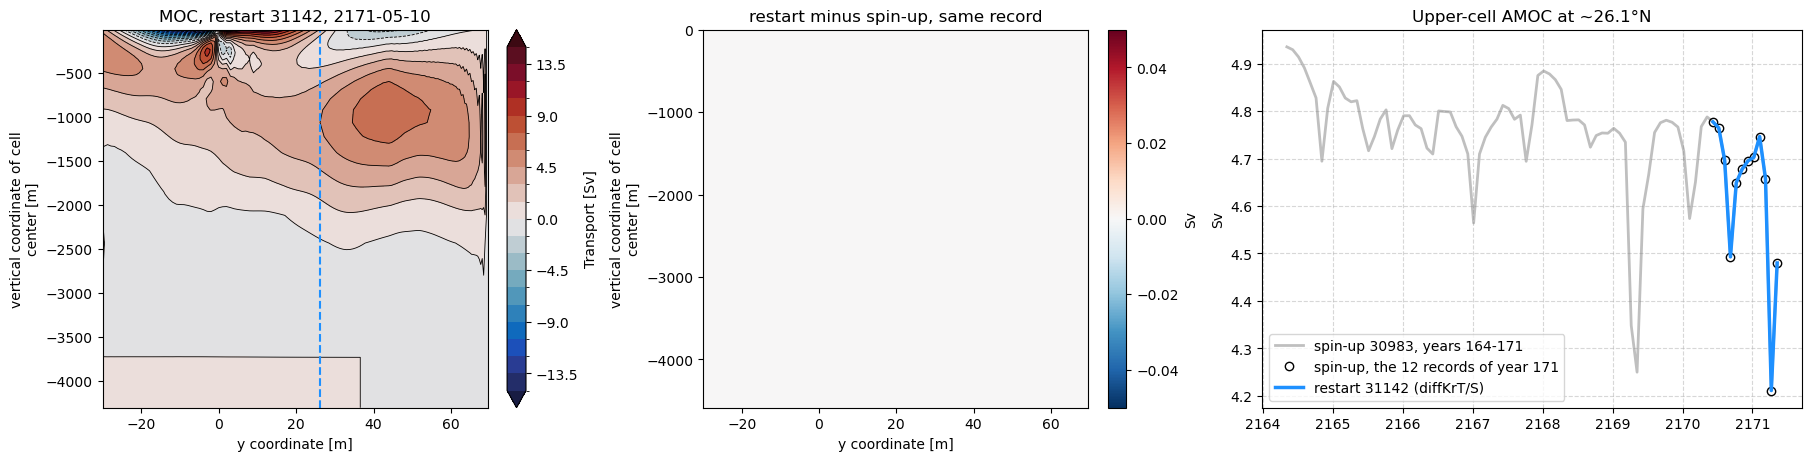

In [4]:
import cmocean
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), gridspec_kw={"width_ratios": [1, 1, 1.4]}, constrained_layout=True)
levels = np.linspace(-15, 15, 21)
p = psi_new.isel(time=-1)
cf = p.plot.contourf(ax=axes[0], x="YC", y="Z", levels=levels, cmap=cmocean.cm.balance, extend="both", add_colorbar=False)
p.plot.contour(ax=axes[0], x="YC", y="Z", levels=levels, colors="k", linewidths=0.6)
fig.colorbar(cf, ax=axes[0], label="Transport [Sv]")
axes[0].set_title(f"MOC, restart 31142, {str(d_new.ds.time.values[-1])[:10]}")
axes[0].axvline(d_new.amoc_lat_sel, color="dodgerblue", ls="--")
axes[0].set_xlim(left=-30); axes[0].set_facecolor("lightgrey")
dpsi = (psi_new - psi_ref).isel(time=-1)
cf2 = dpsi.plot.pcolormesh(ax=axes[1], x="YC", y="Z", cmap="RdBu_r", add_colorbar=False)
fig.colorbar(cf2, ax=axes[1], label="Sv")
axes[1].set_title("restart minus spin-up, same record")
axes[1].set_xlim(left=-30)
axes[2].plot(d_ctx.ds.time.values, d_ctx.amoc_upper_ts.values, color="grey", lw=2, alpha=0.5, label="spin-up 30983, years 164-171")
axes[2].plot(d_ref.ds.time.values, amoc_ref.values, "o", color="k", ms=6, mfc="none", label="spin-up, the 12 records of year 171")
axes[2].plot(d_new.ds.time.values, amoc_new.values, "-", color="dodgerblue", lw=2.5, label="restart 31142 (diffKrT/S)")
axes[2].set_title(f"Upper-cell AMOC at ~{d_new.amoc_lat_sel:.1f}°N"); axes[2].grid(True, ls="--", alpha=0.5); axes[2].legend(loc="lower left")
axes[2].set_ylabel("Sv")
fig.savefig(os.path.join(FIG_DIR, "moc_amoc_restart31142_vs_spinup30983.png"), dpi=120)
plt.show()

## 3. Why no `viscAhGrid` reproduces the viscosity file

DINO's lateral viscosity is NEMO's `nn_ahm_ijk_t = 20` law, A_h = ½·U_v·Δx with
`rn_Uv = 0.27` m/s (the DINO `EXPREF/namelist_cfg`); the production `_2p00`
file is U_v = 0.54. On the Mercator grid Δx = dxC = 111.2 km·cos φ, so the
file is ∝ cos φ. MITgcm's grid-dependent option is
`viscAhGrid·L²/(4Δt)` (`mom_calc_visc.F`, `L2rdt = 0.25·recip_dt·L2`), ∝ cos²φ.
The two can agree at one latitude only. `viscAhReMax` is the closest *concept*
(a floor |u|·L/Re), but it uses the local speed, so it is a state-dependent,
adjoint-active closure — a different model, not a re-expression of the file.

file (2x): 10342 .. 30024 m2/s;  viscAhGrid matching the mean = 2.270e-02, matching the equator = 1.748e-02
grid-law / file ratio, normalised at the equator: 0.34 at -69.9N, 0.35 at 69.5N (= cos phi)


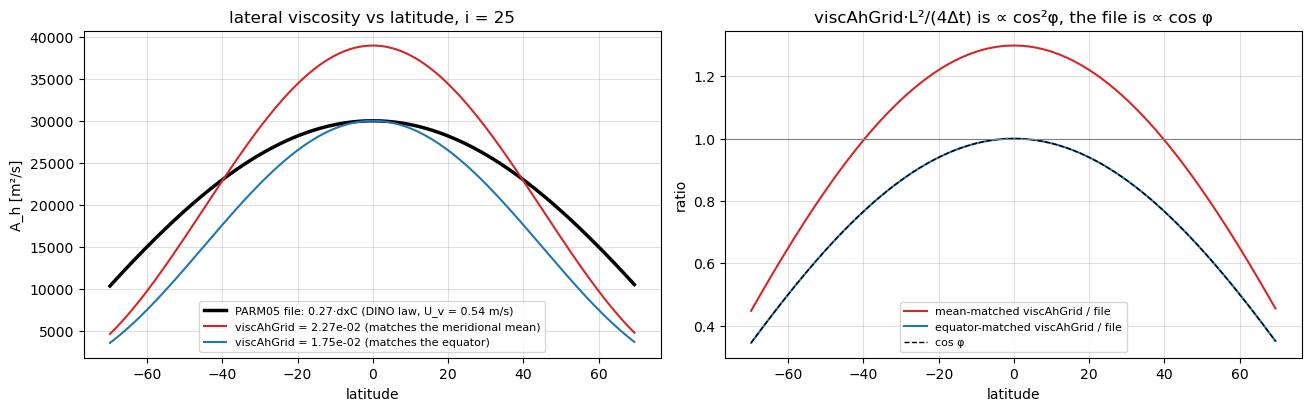

In [5]:
g = np.fromfile(mitgrid, dtype=">f8").reshape((16, NY + 1, NX + 1))
YC, DXC, DYC = g[1][:NY, 25], g[10][:NY, 25], g[11][:NY, 25]
file2x = np.fromfile(os.path.dirname(mitgrid) + "/dino_viscAhD_2p00.bin", dtype=">f8").reshape((NX, NY, NR), order="F")[25, :, 0]
L2rdt = 0.25 * DXC * DYC / delta_t                    # square cells: L2_D = dxF*dyF
g_mean = file2x.mean() / L2rdt.mean()                # viscAhGrid matching the meridional mean of the file
j_eq = np.abs(YC).argmin()
g_eq = file2x[j_eq] / L2rdt[j_eq]                    # viscAhGrid matching the file at the equator
print(f"file (2x): {file2x.min():.0f} .. {file2x.max():.0f} m2/s;  viscAhGrid matching the mean = {g_mean:.3e}, matching the equator = {g_eq:.3e}")
print(f"grid-law / file ratio, normalised at the equator: {(L2rdt/file2x)[0]/(L2rdt/file2x)[j_eq]:.2f} at {YC[0]:.1f}N, {(L2rdt/file2x)[-1]/(L2rdt/file2x)[j_eq]:.2f} at {YC[-1]:.1f}N (= cos phi)")
fig, ax = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
ax[0].plot(YC, file2x, "k", lw=2.5, label="PARM05 file: 0.27·dxC (DINO law, U_v = 0.54 m/s)")
ax[0].plot(YC, g_mean * L2rdt, "C3", label=f"viscAhGrid = {g_mean:.2e} (matches the meridional mean)")
ax[0].plot(YC, g_eq * L2rdt, "C0", label=f"viscAhGrid = {g_eq:.2e} (matches the equator)")
ax[0].set_xlabel("latitude"); ax[0].set_ylabel("A_h [m²/s]"); ax[0].grid(alpha=0.4); ax[0].legend(fontsize=8)
ax[0].set_title("lateral viscosity vs latitude, i = 25")
ax[1].plot(YC, g_mean * L2rdt / file2x, "C3", label="mean-matched viscAhGrid / file")
ax[1].plot(YC, g_eq * L2rdt / file2x, "C0", label="equator-matched viscAhGrid / file")
ax[1].plot(YC, np.cos(np.deg2rad(YC)) / np.cos(np.deg2rad(YC[j_eq])), "k--", lw=1, label="cos φ")
ax[1].axhline(1, color="grey", lw=0.8); ax[1].set_xlabel("latitude"); ax[1].set_ylabel("ratio"); ax[1].grid(alpha=0.4); ax[1].legend(fontsize=8)
ax[1].set_title("viscAhGrid·L²/(4Δt) is ∝ cos²φ, the file is ∝ cos φ")
fig.savefig(os.path.join(FIG_DIR, "viscAhGrid_vs_file_latitude_structure.png"), dpi=120)
plt.show()

## 4. The adjoint-viscosity boost: what the stale `outAd*` values changed

In `data.autodiff_adjointViscosity` the `outAd*` values are written back at the
end of every backward step and are what each checkpoint replay of the forward
model then runs with. Until 2026-09-09 they were `outAdviscAhGrid = 1.8E-2`
and `outAddiffKhT/S = 0` while the forward namelist has `viscAhGrid` unset (0)
and `diffKhT/S = 500`, so every replay after the first backward step carried
an extra `1.8E-2·L²/(4Δt)` of viscosity (31 000 m²/s at the equator) and no
lateral tracer diffusion. Run 31138 is the last run with those values, 31141
the first with the corrected ones (`0.`, `5.E2`); same executable, 30 d from
rest, `viscFacInAd = 10`. `fc` and `%MON` come from the forward sweep and are
expected identical; every sensitivity is expected to differ. For scale, 31026
is the plain (unboosted) adjoint of the same start.

In [6]:
def fields(d, prefix):
    out = {}
    for m in sorted(glob.glob(os.path.join(d, prefix + "*.meta"))):
        base = os.path.basename(m)
        name, it = base.split(".")[0], base.split(".")[-2]
        if ".effective." in base or ".tmp." in base or not it.isdigit():
            continue
        out.setdefault(name, []).append(int(it))
    return out

def read(d, name, it):
    return xu.read_mds(os.path.join(d, name), iternum=it, use_mmap=False, use_dask=False)[name].astype("f8")

def fc_of(d):                     # MPI runs print it in STDOUT.0000, serial runs in output_tap_adj.txt
    for name in ("STDOUT.0000", "output_tap_adj.txt"):
        if os.path.exists(os.path.join(d, name)):
            for line in open(os.path.join(d, name)):
                if "global fc" in line.lower():
                    return line.split(")", 1)[-1].strip()
    return "(no fc line)"

print("fc  31138:", fc_of(boost_ref)); print("fc  31141:", fc_of(boost_new)); print("fc  31026:", fc_of(plain_ref))
rows = []
for prefix in ("ADJ", "adxx_"):
    fn, fr = fields(boost_new, prefix), fields(boost_ref, prefix)
    for name in sorted(set(fn) & set(fr)):
        its = sorted(set(fn[name]) & set(fr[name]))
        num = den = mx = mxr = 0.0; corr_num = corr_a = corr_b = 0.0
        for it in its:
            a, b = read(boost_new, name, it), read(boost_ref, name, it)
            num += ((a - b) ** 2).sum(); den += (b ** 2).sum()
            mx = max(mx, np.abs(a - b).max()); mxr = max(mxr, np.abs(b).max())
            corr_num += (a * b).sum(); corr_a += (a * a).sum(); corr_b += (b * b).sum()
        if den == 0:
            rows.append((name, len(its), "all-zero field", "", ""))
            continue
        rows.append((name, len(its), f"{np.sqrt(num/den):.3f}", f"{mx/mxr:.3f}", f"{corr_num/np.sqrt(corr_a*corr_b):.4f}"))
print(f"{'field':16s} {'dumps':>5s} {'RMS(new-old)/RMS(old)':>22s} {'max|new-old|/max|old|':>22s} {'corr':>7s}")
for r in rows:
    print(f"{r[0]:16s} {r[1]:5d} {r[2]:>22s} {r[3]:>22s} {r[4]:>7s}")

fc  31138: global fc =   3.99075406661494E-01
fc  31141: global fc =   3.99075406661494E-01
fc  31026: global fc =   3.99075406661494E-01


field            dumps  RMS(new-old)/RMS(old)  max|new-old|/max|old|    corr
ADJdiffkr            6                  0.204                  0.259  0.9793
ADJempmr             6                  0.071                  0.086  0.9976
ADJetan              7                  0.007                  0.059  1.0000
ADJqnet              6                  0.146                  0.166  0.9893
ADJqsw               6                  0.122                  0.386  0.9926
ADJsalt              6                  0.105                  0.340  0.9945
ADJtaux              6                  0.013                  0.074  0.9999
ADJtauy              6                  0.007                  0.014  1.0000
ADJtheta             6                  0.104                  0.362  0.9947
ADJuvel              6                  0.022                  0.092  0.9998
ADJvvel              6                  0.038                  0.117  0.9993
ADJwvel              6                  0.030                  0.036  0.9996

ADJtheta at iteration 0 (sensitivity to the initial state, 30-day lead): max|.|  plain 3.961e-02   old boost 3.347e-02   corrected boost 3.349e-02


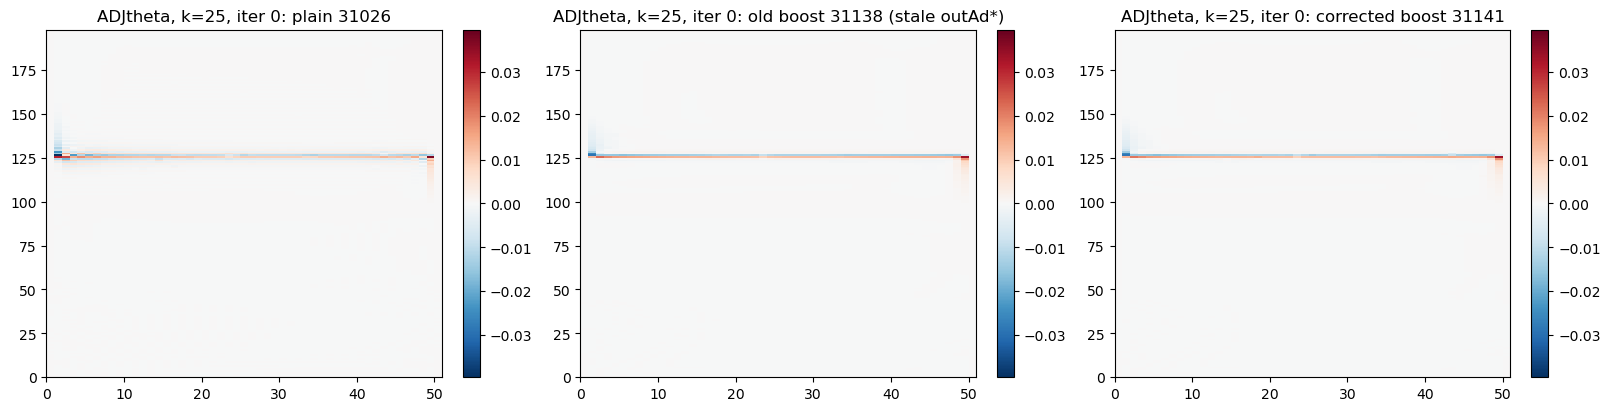

In [7]:
# the scale of the boost itself: the corrected boost (31141) and the old one (31138) against the plain adjoint (31026)
name, it = "ADJtheta", 0
a, b, c = read(boost_new, name, it), read(boost_ref, name, it), read(plain_ref, name, it)
print(f"{name} at iteration {it} (sensitivity to the initial state, 30-day lead): max|.|  plain {np.abs(c).max():.3e}   old boost {np.abs(b).max():.3e}   corrected boost {np.abs(a).max():.3e}")
k = 25
fig, ax = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
v = np.abs(c[k]).max()
for axi, f, t in zip(ax, (c, b, a), ("plain 31026", "old boost 31138 (stale outAd*)", "corrected boost 31141")):
    im = axi.pcolormesh(f[k], cmap="RdBu_r", vmin=-v, vmax=v); axi.set_title(f"{name}, k={k}, iter {it}: {t}"); fig.colorbar(im, ax=axi)
fig.savefig(os.path.join(FIG_DIR, "adjVisc_outAd_fix_ADJtheta_k25_iter0.png"), dpi=110)
plt.show()

## What this establishes

- **`diffKrT`/`diffKrS` are an exact replacement for `diffKrFile`.** With
  `ALLOW_3D_DIFFKR` the 3-D `diffKr` array is initialised from
  `diffKrNrS(k)` and a file only overwrote it with the same constant, so the
  forward and adjoint runs are bitwise identical to their file-based twins,
  and the 1-year restart reproduces the spin-up's own year 171 record for
  record (part 1) — the AMOC overlay in part 2 is the same curve twice.
- **The lateral viscosity stays a `PARM05` file, on purpose.** The file is
  DINO's A_h = ½·U_v·Δx law on the grid (part 3) and MITgcm has no parameter
  linear in Δx; `scripts/gen_viscAhD.py` now regenerates every
  `dino_viscAhD*.bin` byte for byte, so the file is a documented function of
  the grid and one number rather than an opaque input. Keeping it is also what
  makes the stock adjoint-mode factor `viscFacInAd` act at all: it multiplies
  only file-based viscosity fields (`mom_calc_visc.F:509-511`).
- **The adjoint-viscosity boost had stale `outAd*` values** (part 4); every
  boosted run up to 31138 replayed the forward model with extra viscosity and
  no lateral tracer diffusion. Fixed; the sensitivities change at the level the
  table above reports, `fc` does not.